# FreshMart Business Strategy
### Taking A Look Into the Loyalty App-- Does it Increase Sales?

## Part 1 – Setup a Notebook to Brief Your Stakeholders

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy import stats

In [3]:
df = pd.read_csv('../Data/freshmart_spend.csv')

In [4]:
df.head()

,group,spend
0,App User,65.450712
1,App User,55.926035
2,App User,67.715328
3,App User,80.845448
4,App User,54.487699


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   group   400 non-null    object 
 1   spend   400 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.4+ KB


In [6]:
df.groupby('group').describe()

spend                                                         \
          count       mean        std        min        25%        50%   
group                                                                    
App User  200.0  57.388436  13.965059  18.703823  47.423085  57.937122   
Non-User  200.0  53.288023  14.805057   3.380990  42.912437  53.182590   

                                 
                75%         max  
group                            
App User  65.512787   98.802537  
Non-User  62.308467  109.790972

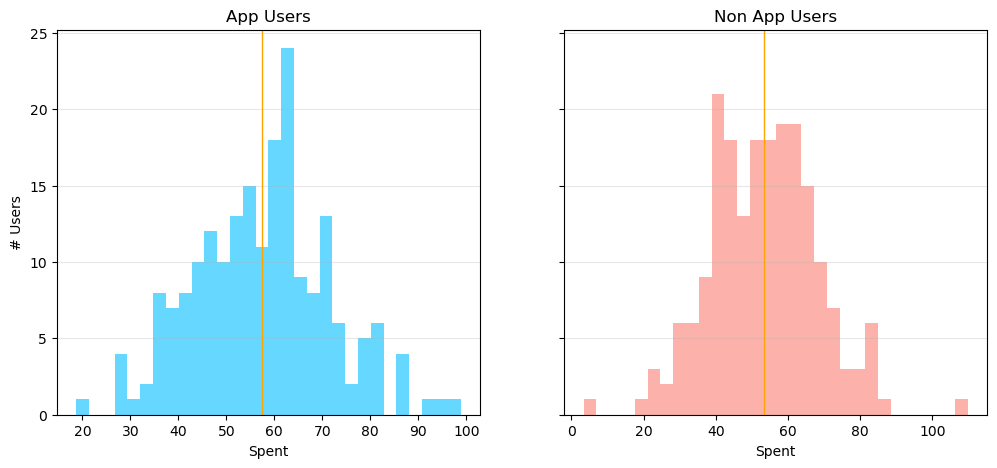

In [7]:
app_user = df[df['group']== 'App User']
non_user = df[df['group']== 'Non-User']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].hist(app_user['spend'], bins=30, color='deepskyblue', alpha=0.6)
axes[0].set_title('App Users')
axes[0].set_xlabel('Spent')
axes[0].set_ylabel('# Users')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline((app_user['spend'].mean()), color='orange', linewidth=1)
axes[1].hist(non_user['spend'], bins=30, color='salmon', alpha=0.6)
axes[1].set_xlabel('Spent')
axes[1].set_title('Non App Users')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axvline((non_user['spend'].mean()), color='orange', linewidth=1)
plt.show()

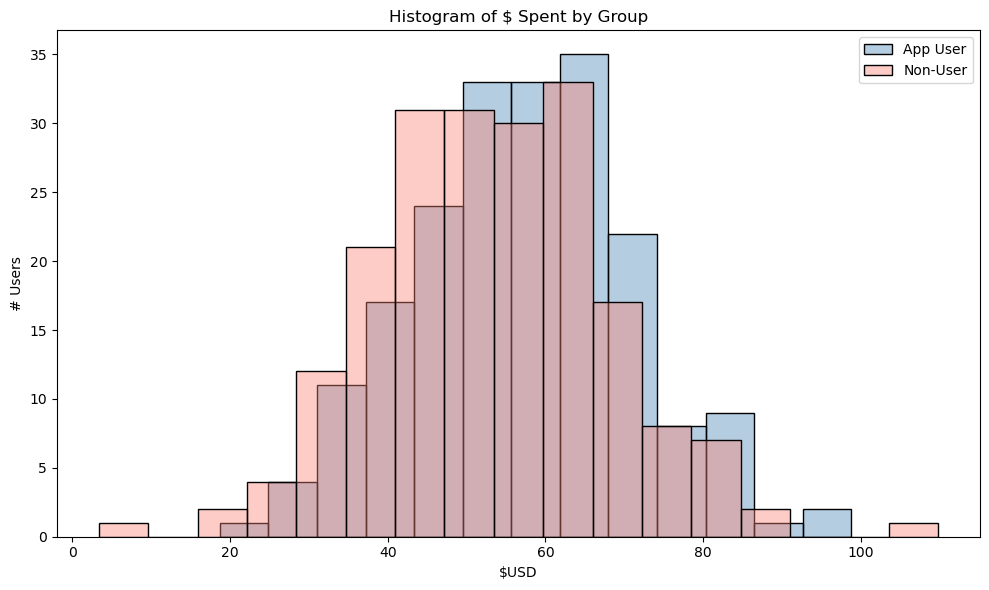

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

app_user = df[df['group'] == 'App User']
non_user = df[df['group'] == 'Non-User']

plt.figure(figsize=(10,6))

sns.histplot(app_user['spend'], 
             color='steelblue', 
             label='App User', 
             kde=False, 
             stat='count',
             alpha=0.4)

sns.histplot(non_user['spend'], 
             color='salmon', 
             label='Non-User', 
             kde=False, 
             stat='count',
             alpha=0.4)

plt.xlabel('$USD')
plt.ylabel('# Users')
plt.title('Histogram of $ Spent by Group')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\hungh\AppData\Local\Temp\ipykernel_14380\3795793755.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([app_user['spend'], non_user['spend']], labels=['App User', 'Non-User'],


{'whiskers': [<matplotlib.lines.Line2D at 0x10afe6dfb10>,
 'caps': [<matplotlib.lines.Line2D at 0x10afe6dfd90>,
 'boxes': [<matplotlib.patches.PathPatch at 0x10afe1e34d0>,
 'medians': [<matplotlib.lines.Line2D at 0x10afe724050>,
 'fliers': [<matplotlib.lines.Line2D at 0x10afe724190>,
 'means': []}

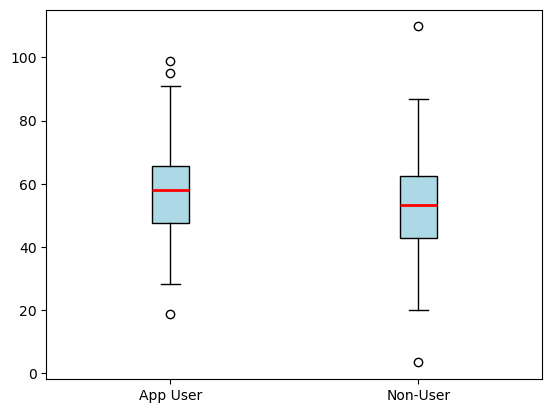

In [9]:
plt.boxplot([app_user['spend'], non_user['spend']], labels=['App User', 'Non-User'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)

- Both groups seem to be normal enough to use a t-test without incorrect assumptions/skewing data.

## Part 2 – Independent t-Test

Null Hypothesis: App User do not spend more  than the non-app user.
Alternative Hypothesis: With loyality app, app users will spend more. 

In [10]:
t_stat, p_value = stats.ttest_ind(app_user['spend'], non_user['spend'], equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

T-statistic: 2.8493, P-value: 0.0046


Data show that it's significant enough that app users will spend more than non-app users if there's a loyality app involved.

# Part 3 – Simulating Best-Case and Worst-Case Monthly Profit

In [35]:
# Sum both to get total revenue for that scenario.

app_user_spend = np.random.normal(loc = app_user['spend'].mean(), scale = app_user['spend'].std(), size = 1_000).sum() 
non_user_spend = np.random.normal(loc = non_user['spend'].mean(), scale = non_user['spend'].std() , size = 5_000).sum()
total_spend = app_user_spend + non_user_spend
round(total_spend, 2)

np.float64(323171.94)

In [ ]:
# Subtract the fixed cost from each scenario’s total revenue to get profit.
fixed_costs = 292_000
total_revenue = total_spend - fixed_costs 
round(total_revenue, 2)


np.float64(31171.94)

 Avg Stimulated profit: $31842.31
 5th and 95th: 29965.48, 33732.99


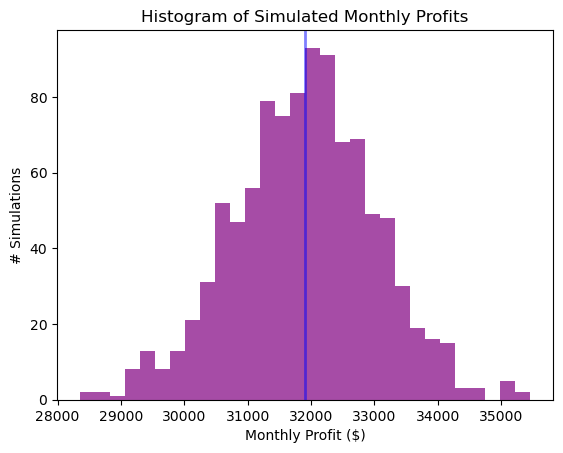

In [74]:
# Plot a histogram of the 1,000 profit estimates.

def stimulated_revenue():
    stimulated_profits = []
    for _ in range(1000):
        app_user_spend = np.random.normal(loc = app_user['spend'].mean(), scale = app_user['spend'].std(), size = 1_000).sum() 
        non_user_spend = np.random.normal(loc = non_user['spend'].mean(), scale = non_user['spend'].std() , size = 5_000).sum()
        total_spend = app_user_spend + non_user_spend
        total_revenue = round(total_spend - fixed_costs, 2) 
        stimulated_profits.append(total_revenue)
    return stimulated_profits

stimulated_1k = stimulated_revenue()
print(f' Avg Stimulated profit: ${ round(np.mean(stimulated_1k),2)}')
# 5th, 95th np percentiles
lower_bound = round(np.percentile(stimulated_1k, 5), 2)
upper_bound = round(np.percentile(stimulated_1k, 95), 2) 
print(f' 5th and 95th: {lower_bound}, {upper_bound}')

plt.hist(stimulated_profits, bins=30, color='purple', alpha=0.7)
plt.title('Histogram of Simulated Monthly Profits')
plt.xlabel('Monthly Profit ($)')
plt.ylabel('# Simulations')
plt.axvline(np.mean(stimulated_profits), color='blue', alpha =0.5, linewidth=2, label='Mean Profit')
plt.show()


For Freshmart to remain profitable, they can't exceed business' fixed cost (292,000) plus 5th percentitle (worst_case) which estimated around 322K. So, the threshold to have cash flow positive is not to exceed 322K.
